In [32]:

# H1: Properties located at specific geographic coordinates (latitude and longitude) 
#     that are NOT waterfront are more likely to provide Smaller lot sizes. 
# #### Turned out to be True!!!!


# H2: Properties that are characterized by either having at least 
#     four bathrooms or having a larger living area than neighboring 
#     properties have relatively higher grades.
# #### Turned out to be RELATIVELY TRUE!!!!


# H3: Properties that are historically older but in good condition are more likely to be 
#     in original format and not been renovated, preserving their original architectural character.
# #### Turned out to be COMPLETELY TRUE!!!!


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D projection


In [34]:
# read the data frame
df = pd.read_csv('data/df_cleaned.csv')

In [35]:
# Setting thresholds
lot_thre = df['sqft_lot'].quantile(0.95)

historic_thre = 70

condition_thre = np.median(df['condition'].unique())

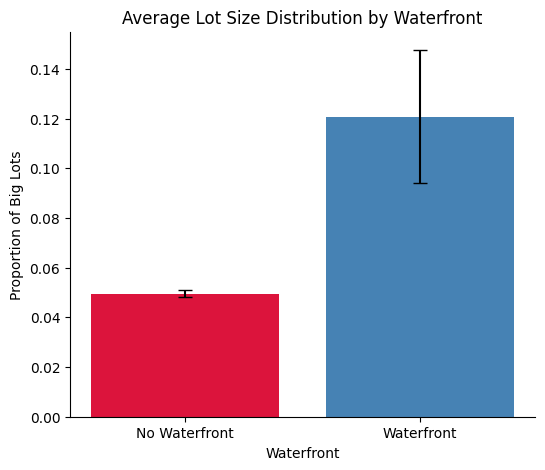

In [36]:
# Hypo1 Flags
df['is_big_lot'] = df['sqft_lot'] > lot_thre

grouped = df.groupby('waterfront')['is_big_lot']
means = grouped.mean() # mean
sems = grouped.sem()  # standard error

# Plot
fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    means.index,
    means.values,
    yerr=sems.values,  # error bars
    color=['crimson', 'steelblue'],
    capsize=5   # to add caps to error bars
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['No Waterfront', 'Waterfront'], rotation=0)
ax.set_ylabel("Proportion of Big Lots")
ax.set_xlabel("Waterfront")
ax.set_title("Average Lot Size Distribution by Waterfront")

# Clean frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()


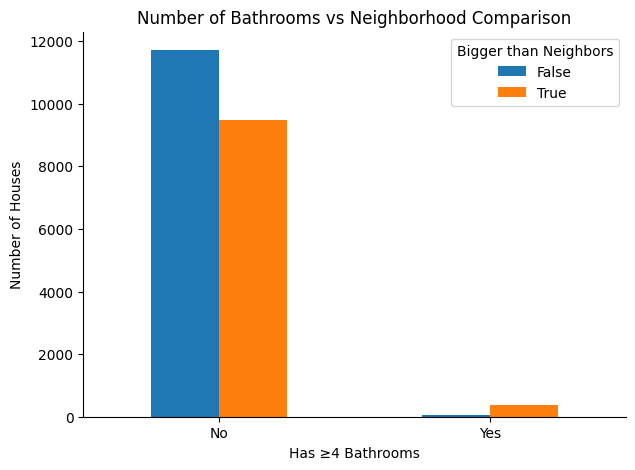

In [37]:
# Hypo2 Flags
df['4_bath'] = df['bathrooms'] >= 4
df['is_locally_dominant'] = df['sqft_living'] > df['sqft_living15']

# Combined condition
df['meets_h2'] = df['4_bath'] | df['is_locally_dominant']

# Plot
h2_ct = pd.crosstab(df['4_bath'], df['is_locally_dominant'])

fig, ax = plt.subplots(figsize=(7, 5))
h2_ct.plot(kind='bar', ax=ax)

ax.set_xlabel("Has ≥4 Bathrooms")
ax.set_ylabel("Number of Houses")
ax.set_title("Number of Bathrooms vs Neighborhood Comparison")

ax.set_xticks([0, 1])
ax.set_xticklabels(['No', 'Yes'], rotation=0)

ax.legend(title="Bigger than Neighbors")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

/var/folders/3l/slblcrbj32b37hg9lcbsc9fc0000gn/T/ipykernel_2222/2488961224.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('magma')


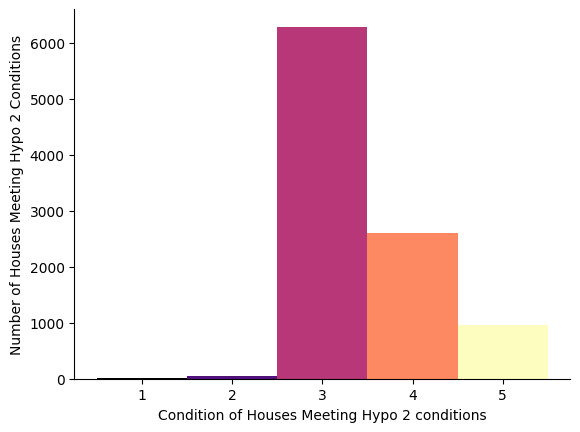

In [38]:
cmap = plt.cm.get_cmap('magma')
colors = cmap(np.linspace(0, 1, 5))

bins = np.arange(0.5, 6.5, 1)

counts, bins, patches = plt.hist(
    df[df['meets_h2']]['condition'],
    bins=bins
)

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

plt.xlabel("Condition of Houses Meeting Hypo 2 conditions")
plt.ylabel("Number of Houses Meeting Hypo 2 Conditions")

# Remove top and right frames
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xticks([1, 2, 3, 4, 5])

plt.show()

/var/folders/3l/slblcrbj32b37hg9lcbsc9fc0000gn/T/ipykernel_2222/39627238.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['bigger_than_neighbors'] = plot_data['sqft_living'] > plot_data['sqft_living15']
/var/folders/3l/slblcrbj32b37hg9lcbsc9fc0000gn/T/ipykernel_2222/39627238.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('magma')


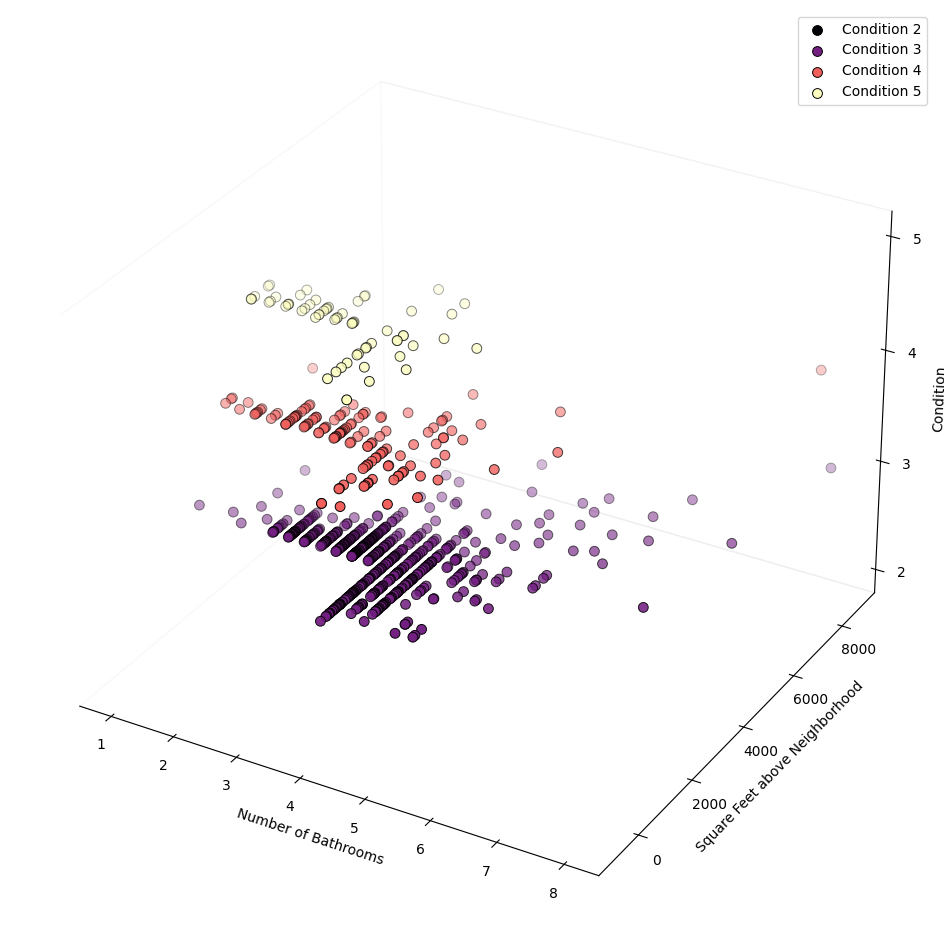

In [39]:
df['locally_dominant'] = df['sqft_living'] - df['sqft_living15']
plot_data = df[(df['bathrooms'] >= 4) | (df['locally_dominant'] > 1500.)]

plot_data['bigger_than_neighbors'] = plot_data['sqft_living'] > plot_data['sqft_living15']

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

x = plot_data['bathrooms']
y = plot_data['locally_dominant']
z = plot_data['condition']

levels = [2, 3, 4, 5]
cmap = plt.cm.get_cmap('magma')
colors = cmap(np.linspace(0, 1, len(levels)))

for level, color in zip(levels, colors):
    mask = (z == level)
    ax.scatter(
        x[mask],
        y[mask],
        z[mask],
        color=color,
        edgecolors='black',   
        linewidths=0.7,      
        s=50,                 
        label=f'Condition {level}'
    )

ax.set_xlabel('Number of Bathrooms')
ax.set_ylabel('Square Feet above Neighborhood')
ax.set_zlabel('Condition')

ax.set_zticks(levels)

ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(False)

ax.legend()

plt.show()


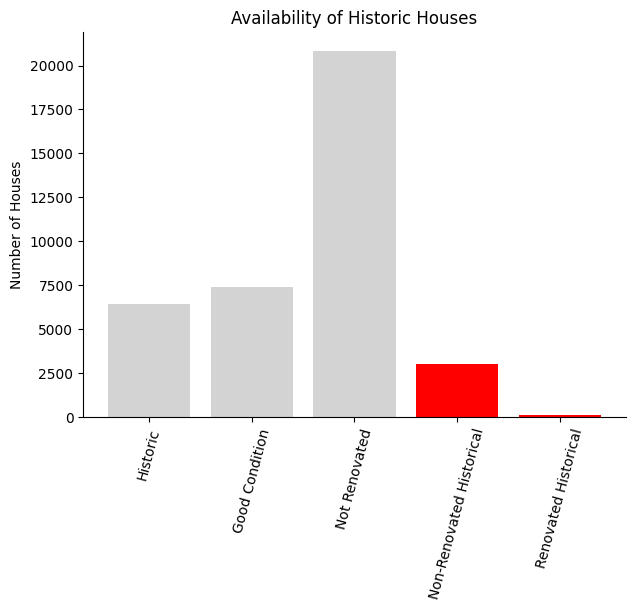

In [40]:

# Hypo3 Flags
df['is_historic'] = df['house_age'] > historic_thre
df['is_good_condition'] = df['condition'] > condition_thre
df['is_not_renovated'] = df['if_renovated'] == 0
df['is_renovated'] = df['if_renovated'] == 1

df['histo_orig'] = (
    df['is_historic'] &
    df['is_good_condition'] &
    df['is_not_renovated']
)

df['histo_reno'] = (
    df['is_historic'] &
    df['is_good_condition'] &
    df['is_renovated']
)


# Plot
h3_counts = [
    df['is_historic'].sum(),
    df['is_good_condition'].sum(),
    df['is_not_renovated'].sum(),
    df['histo_orig'].sum(),
    df['histo_reno'].sum(),
]

labels = [
    "Historic",
    "Good Condition",
    "Not Renovated",
    "Non-Renovated Historical",
    "Renovated Historical"
]

# Define colors (last two are different)
colors = [
    "lightgray",   # Historic
    "lightgray",   # Good Condition
    "lightgray",   # Not Renovated
    "red",   # Non-renovated historical
    "red"    # Renovated historical
]

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(labels, h3_counts, color=colors)

ax.set_ylabel("Number of Houses")
ax.set_title("Availability of Historic Houses")

plt.xticks(rotation=75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [41]:
df.columns

Index(['id', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'date', 'price', 'house_age',
       'if_renovated', 'is_big_lot', '4_bath', 'is_locally_dominant',
       'meets_h2', 'locally_dominant', 'is_historic', 'is_good_condition',
       'is_not_renovated', 'is_renovated', 'histo_orig', 'histo_reno'],
      dtype='object')

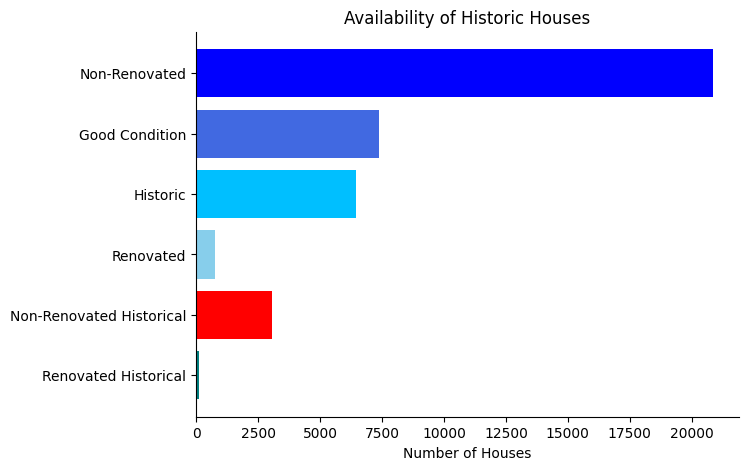

In [43]:
steps = [
    df['is_not_renovated'].sum(),
    df['is_good_condition'].sum(),
    df['is_historic'].sum(),
    df['is_renovated'].sum(),
    df['histo_orig'].sum(),
    df['histo_reno'].sum(),
]

labels = [
    "Non-Renovated",
    "Good Condition",
    "Historic",
    "Renovated",
    "Non-Renovated Historical",
    "Renovated Historical"
]

# Define colors (last two are different)
colors = [
    "blue",   
    "royalblue",   
    "deepskyblue", 
    "skyblue",
    "red",   
    "teal"    
]

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(labels, steps, color=colors)
ax.set_title("Availability of Historic Houses")
ax.set_xlabel("Number of Houses")

plt.gca().invert_yaxis()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()